# 01 - Store Sales Forecasting - Baseline LightGBM (Correct Time Series Pipeline)

## Objective
Build a baseline forecasting model using a temporally consistent dataset.

Main goals:
- preserve the chronological structure of each store-family time series
- create reliable lag features
- avoid data leakage
- evaluate a first LightGBM baseline with RMSLE

## Pipeline Overview

The baseline pipeline follows these steps:

1. Load and inspect the dataset
2. Sort data by (store_nbr, family, date) to preserve temporal structure
3. Select a temporally consistent subset (last N days)
4. Create calendar-based features
5. Generate lag features per time series
6. Remove rows with missing lag values
7. Encode categorical variables
8. Split data chronologically
9. Train LightGBM baseline model
10. Evaluate performance using RMSLE

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from lightgbm import LGBMRegressor
from sklearn.metrics import mean_squared_log_error

In [2]:
SEED = 42
DATA_DIR = Path("../data")
TARGET = "sales"

USE_FULL_DATA = False
LAST_N_DAYS = 365

print("Setup OK")
print("Data dir:", DATA_DIR.resolve())

Setup OK
Data dir: /home/donatocorbacio/projects/store-sales-project/data


In [3]:
train = pd.read_csv(DATA_DIR / "train.csv", parse_dates=["date"])
test = pd.read_csv(DATA_DIR / "test.csv", parse_dates=["date"])

print("Train shape:", train.shape)
print("Test shape:", test.shape)
display(train.head())

Train shape: (3000888, 6)
Test shape: (28512, 5)


,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


In [4]:
print("Train range:", train["date"].min(), "->", train["date"].max())
print("Test range:", test["date"].min(), "->", test["date"].max())

Train range: 2013-01-01 00:00:00 -> 2017-08-15 00:00:00
Test range: 2017-08-16 00:00:00 -> 2017-08-31 00:00:00


In [5]:
train.tail(10)

,id,date,store_nbr,family,sales,onpromotion
3000878,3000878,2017-08-15,9,MAGAZINES,11.000,0
3000879,3000879,2017-08-15,9,MEATS,449.228,0
3000880,3000880,2017-08-15,9,PERSONAL CARE,522.000,11
3000881,3000881,2017-08-15,9,PET SUPPLIES,6.000,0
3000882,3000882,2017-08-15,9,PLAYERS AND ELECTRONICS,6.000,0
3000883,3000883,2017-08-15,9,POULTRY,438.133,0
3000884,3000884,2017-08-15,9,PREPARED FOODS,154.553,1
3000885,3000885,2017-08-15,9,PRODUCE,2419.729,148
3000886,3000886,2017-08-15,9,SCHOOL AND OFFICE SUPPLIES,121.000,8
3000887,3000887,2017-08-15,9,SEAFOOD,16.000,0


In [6]:
test.tail(10)

,id,date,store_nbr,family,onpromotion
28502,3029390,2017-08-31,9,MAGAZINES,0
28503,3029391,2017-08-31,9,MEATS,20
28504,3029392,2017-08-31,9,PERSONAL CARE,14
28505,3029393,2017-08-31,9,PET SUPPLIES,0
28506,3029394,2017-08-31,9,PLAYERS AND ELECTRONICS,0
28507,3029395,2017-08-31,9,POULTRY,1
28508,3029396,2017-08-31,9,PREPARED FOODS,0
28509,3029397,2017-08-31,9,PRODUCE,1
28510,3029398,2017-08-31,9,SCHOOL AND OFFICE SUPPLIES,9
28511,3029399,2017-08-31,9,SEAFOOD,0


In [7]:
print("\nTrain info:")
train.info()

print("\nMissing values:")
display(train.isnull().sum())

print("\nDate range:")
print("Min date:", train["date"].min())
print("Max date:", train["date"].max())


Train info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000888 entries, 0 to 3000887
Data columns (total 6 columns):
 #   Column       Dtype         
---  ------       -----         
 0   id           int64         
 1   date         datetime64[ns]
 2   store_nbr    int64         
 3   family       object        
 4   sales        float64       
 5   onpromotion  int64         
dtypes: datetime64[ns](1), float64(1), int64(3), object(1)
memory usage: 137.4+ MB

Missing values:


id             0
date           0
store_nbr      0
family         0
sales          0
onpromotion    0
dtype: int64


Date range:
Min date: 2013-01-01 00:00:00
Max date: 2017-08-15 00:00:00


## Data preprocessing
Sort the dataset by `store_nbr`, `family`, and `date` before creating lag features.

This is essential in panel time series forecasting because lag features must be computed on a temporally ordered series.

In [8]:
train = train.sort_values(["store_nbr", "family", "date"]).copy()
test = test.sort_values(["store_nbr", "family", "date"]).copy()

print("Sorting completed.")
display(train.head())

Sorting completed.


,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1782,1782,2013-01-02,1,AUTOMOTIVE,2.0,0
3564,3564,2013-01-03,1,AUTOMOTIVE,3.0,0
5346,5346,2013-01-04,1,AUTOMOTIVE,3.0,0
7128,7128,2013-01-05,1,AUTOMOTIVE,5.0,0


## Temporal subset
To keep the baseline fast and technically correct, use the most recent portion of the dataset.

This preserves temporal continuity, unlike random row sampling.

In [9]:
if not USE_FULL_DATA:
    cutoff_date = train["date"].max() - pd.Timedelta(days=LAST_N_DAYS)
    train = train[train["date"] >= cutoff_date].copy()
    print(f"Using temporal subset: last {LAST_N_DAYS} days")
    print("Cutoff date:", cutoff_date)
else:
    print("Using full dataset")

print("Train shape after temporal selection:", train.shape)
print("New date range:", train["date"].min(), "->", train["date"].max())

Using temporal subset: last 365 days
Cutoff date: 2016-08-15 00:00:00
Train shape after temporal selection: (650430, 6)
New date range: 2016-08-15 00:00:00 -> 2017-08-15 00:00:00


## Time-based feature engineering
Create basic calendar features to help the model capture temporal structure.

In [10]:
for df in [train, test]:
    df["year"] = df["date"].dt.year
    df["month"] = df["date"].dt.month
    df["day"] = df["date"].dt.day
    df["dayofweek"] = df["date"].dt.dayofweek
    df["weekofyear"] = df["date"].dt.isocalendar().week.astype(int)

display(train[["date", "year", "month", "day", "dayofweek", "weekofyear"]].head())

,date,year,month,day,dayofweek,weekofyear
2350458,2016-08-15,2016,8,15,0,33
2352240,2016-08-16,2016,8,16,1,33
2354022,2016-08-17,2016,8,17,2,33
2355804,2016-08-18,2016,8,18,3,33
2357586,2016-08-19,2016,8,19,4,33


## Lag features
Lag features are computed separately for each `(store_nbr, family)` series.

In this baseline:
- `lag_1`: previous observed sales value
- `lag_7`: sales value 7 steps before

Since the data is now temporally consistent, these lag features are meaningful.

In [11]:
group_cols = ["store_nbr", "family"]

train["lag_1"] = train.groupby(group_cols)[TARGET].shift(1)
train["lag_7"] = train.groupby(group_cols)[TARGET].shift(7)

display(
    train[["date", "store_nbr", "family", "sales", "lag_1", "lag_7"]].head(15)
)

,date,store_nbr,family,sales,lag_1,lag_7
2350458,2016-08-15,1,AUTOMOTIVE,4.0,NaN,NaN
2352240,2016-08-16,1,AUTOMOTIVE,5.0,4.0,NaN
2354022,2016-08-17,1,AUTOMOTIVE,4.0,5.0,NaN
2355804,2016-08-18,1,AUTOMOTIVE,6.0,4.0,NaN
2357586,2016-08-19,1,AUTOMOTIVE,12.0,6.0,NaN
2359368,2016-08-20,1,AUTOMOTIVE,6.0,12.0,NaN
2361150,2016-08-21,1,AUTOMOTIVE,0.0,6.0,NaN
2362932,2016-08-22,1,AUTOMOTIVE,2.0,0.0,4.0
2364714,2016-08-23,1,AUTOMOTIVE,3.0,2.0,5.0
2366496,2016-08-24,1,AUTOMOTIVE,8.0,3.0,4.0


## Data cleaning
Rows with missing lag values are removed.

These are expected at the beginning of each store-family series.

In [12]:
train = train.dropna(subset=["lag_1", "lag_7"]).copy()

print("Train shape after lag cleaning:", train.shape)
display(train.head())

Train shape after lag cleaning: (637956, 13)


,id,date,store_nbr,family,sales,onpromotion,year,month,day,dayofweek,weekofyear,lag_1,lag_7
2362932,2362932,2016-08-22,1,AUTOMOTIVE,2.0,0,2016,8,22,0,34,0.0,4.0
2364714,2364714,2016-08-23,1,AUTOMOTIVE,3.0,0,2016,8,23,1,34,2.0,5.0
2366496,2366496,2016-08-24,1,AUTOMOTIVE,8.0,0,2016,8,24,2,34,3.0,4.0
2368278,2368278,2016-08-25,1,AUTOMOTIVE,2.0,0,2016,8,25,3,34,8.0,6.0
2370060,2370060,2016-08-26,1,AUTOMOTIVE,7.0,0,2016,8,26,4,34,2.0,12.0


## Encoding
Convert the `family` categorical variable into numeric codes for modeling.

In [13]:
train["family"] = train["family"].astype("category")
test["family"] = test["family"].astype("category")

family_mapping = dict(enumerate(train["family"].cat.categories))

train["family"] = train["family"].cat.codes
test["family"] = test["family"].cat.codes

print("Family encoding completed.")
print("Number of encoded families:", len(family_mapping))

Family encoding completed.
Number of encoded families: 33


## Feature selection
Define the baseline feature set.

In [14]:
features = [
    "store_nbr",
    "family",
    "onpromotion",
    "year",
    "month",
    "day",
    "dayofweek",
    "weekofyear",
    "lag_1",
    "lag_7",
]

X = train[features]
y = train[TARGET]

print("Selected features:")
print(features)
print("\nX shape:", X.shape)
print("y shape:", y.shape)

Selected features:
['store_nbr', 'family', 'onpromotion', 'year', 'month', 'day', 'dayofweek', 'weekofyear', 'lag_1', 'lag_7']

X shape: (637956, 10)
y shape: (637956,)


## Train / validation split
Use a chronological split to preserve temporal order and avoid leakage.

In [15]:
split_date = train["date"].quantile(0.8)

train_data = train[train["date"] < split_date].copy()
val_data = train[train["date"] >= split_date].copy()

X_train = train_data[features]
y_train = train_data[TARGET]

X_val = val_data[features]
y_val = val_data[TARGET]

print("Split date:", split_date)
print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Train date range:", train_data["date"].min(), "->", train_data["date"].max())
print("Val date range:", val_data["date"].min(), "->", val_data["date"].max())

Split date: 2017-06-05 00:00:00
Train shape: (509652, 10)
Validation shape: (128304, 10)
Train date range: 2016-08-22 00:00:00 -> 2017-06-04 00:00:00
Val date range: 2017-06-05 00:00:00 -> 2017-08-15 00:00:00


## Model training
Train a baseline LightGBM regressor on the selected features.

In [16]:
model = LGBMRegressor(
    n_estimators=200,
    learning_rate=0.05,
    num_leaves=31,
    random_state=SEED,
    n_jobs=-1
)

model.fit(X_train, y_train)

print("Model training completed.")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.011834 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 924
[LightGBM] [Info] Number of data points in the train set: 509652, number of used features: 10
[LightGBM] [Info] Start training from score 472.846958
Model training completed.


## Validation predictions
Generate predictions on the validation set.

Predictions are clipped at zero because sales cannot be negative.

In [17]:
y_pred = model.predict(X_val)
y_pred = np.clip(y_pred, 0, None)

print("First predictions:", y_pred[:10])

First predictions: [3.56760568 5.95386657 4.12980225 5.05563394 4.83000755 4.12810499
 4.84898827 3.29496974 4.79043943 4.99761736]


## Baseline evaluation
Use RMSLE as the main metric, since it is the competition metric and is suitable for scaled sales values.

In [18]:
rmsle = np.sqrt(mean_squared_log_error(y_val, y_pred))

print("Validation RMSLE:", rmsle)

Validation RMSLE: 0.7823800132116003


## Validation results
Build a small validation table for inspection.

In [19]:
results = val_data[["date", "store_nbr", "family", "sales"]].copy()
results["y_pred"] = y_pred
results["abs_error"] = np.abs(results["sales"] - results["y_pred"])

display(results.head())

,date,store_nbr,family,sales,y_pred,abs_error
2872584,2017-06-05,1,0,6.0,3.567606,2.432394
2874366,2017-06-06,1,0,2.0,5.953867,3.953867
2876148,2017-06-07,1,0,7.0,4.129802,2.870198
2877930,2017-06-08,1,0,1.0,5.055634,4.055634
2879712,2017-06-09,1,0,1.0,4.830008,3.830008


## Visualization
Compare true sales and predicted sales on the validation set.

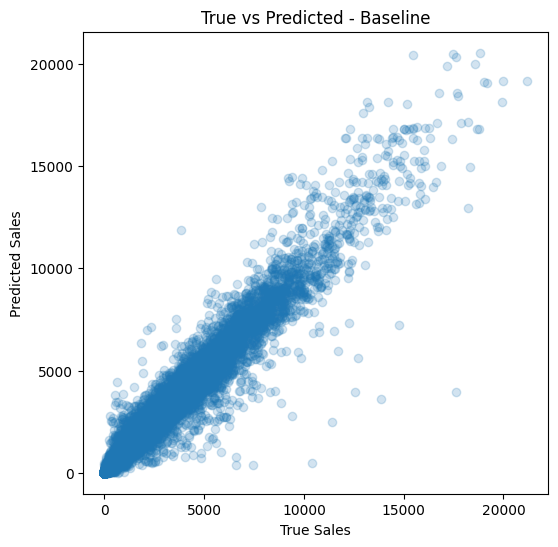

In [20]:
plt.figure(figsize=(6, 6))
plt.scatter(results["sales"], results["y_pred"], alpha=0.2)
plt.xlabel("True Sales")
plt.ylabel("Predicted Sales")
plt.title("True vs Predicted - Baseline")
plt.show()

## First error analysis
Check whether the model performs differently across days of the week.

dayofweek
0    64.592626
1    57.931960
2    56.437987
3    55.744803
4    64.226801
5    80.394433
6    93.685396
Name: abs_error, dtype: float64


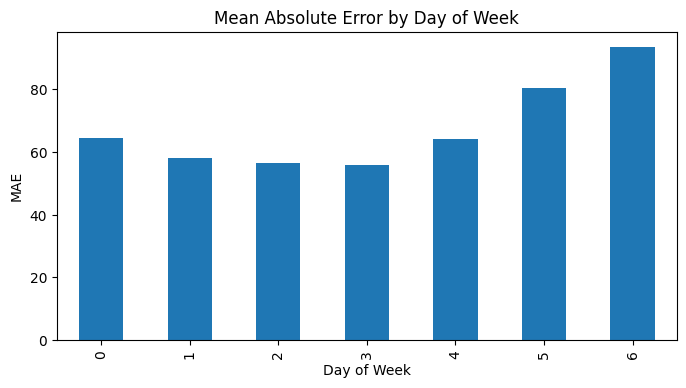

In [21]:
error_by_dayofweek = (
    results.groupby(val_data["dayofweek"])["abs_error"]
    .mean()
    .sort_index()
)

print(error_by_dayofweek)

plt.figure(figsize=(8, 4))
error_by_dayofweek.plot(kind="bar")
plt.title("Mean Absolute Error by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("MAE")
plt.show()

## Conclusion
This notebook establishes a technically correct baseline for the Store Sales forecasting task.

Main outcomes:
- the pipeline preserves temporal consistency
- lag features are now computed on continuous store-family series
- chronological validation avoids leakage
- the resulting baseline can be used as a reliable foundation for:
  - deeper error analysis
  - advanced feature engineering
  - trend and seasonality improvements
  - multi-step forecasting